In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset (using a raw GitHub link for a popular NYC Uber subset)
url = "https://raw.githubusercontent.com/fivethirtyeight/uber-tlc-foil-response/master/uber-trip-data/uber-raw-data-sep14.csv"
print("Downloading dataset...")
df = pd.read_csv(url)

# 2. Convert the 'Date/Time' column to actual datetime objects
print("Converting timestamps...")
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# 3. Feature Engineering: Extract time components
df['Hour'] = df['Date/Time'].dt.hour
df['DayOfWeek'] = df['Date/Time'].dt.day_name()
df['Day'] = df['Date/Time'].dt.day

print(f"Data ready! Total records: {len(df)}")
df.head()

Converting timestamps...
Data ready! Total records: 1028136


,Date/Time,Lat,Lon,Base,Hour,DayOfWeek,Day
0,2014-09-01 00:01:00,40.2201,-74.0021,B02512,0,Monday,1
1,2014-09-01 00:01:00,40.7500,-74.0027,B02512,0,Monday,1
2,2014-09-01 00:03:00,40.7559,-73.9864,B02512,0,Monday,1
3,2014-09-01 00:06:00,40.7450,-73.9889,B02512,0,Monday,1
4,2014-09-01 00:11:00,40.8145,-73.9444,B02512,0,Monday,1


/tmp/ipykernel_3494/637286723.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Hour', palette='viridis')


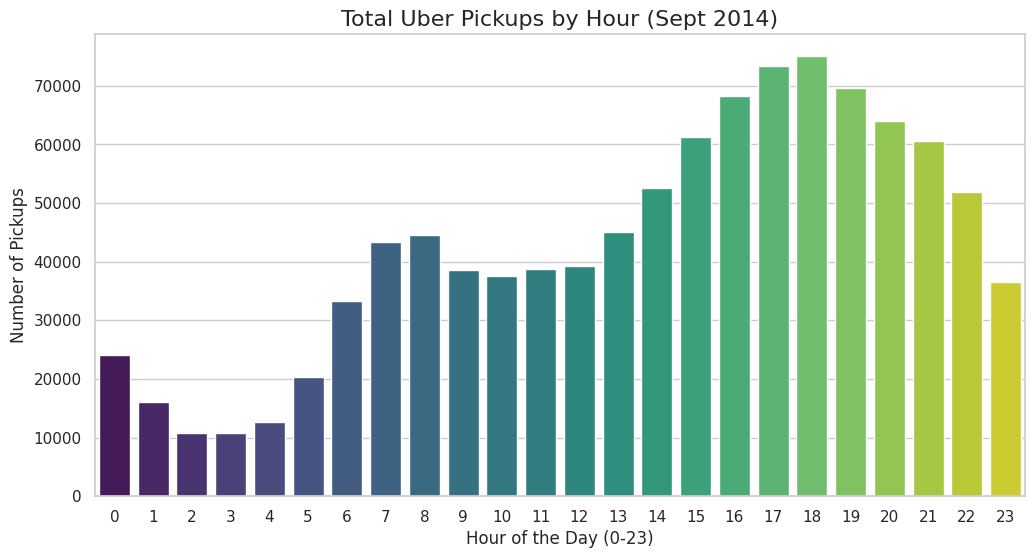

In [2]:
# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Create a countplot for hours
sns.countplot(data=df, x='Hour', palette='viridis')
plt.title('Total Uber Pickups by Hour (Sept 2014)', fontsize=16)
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Number of Pickups')
plt.show()

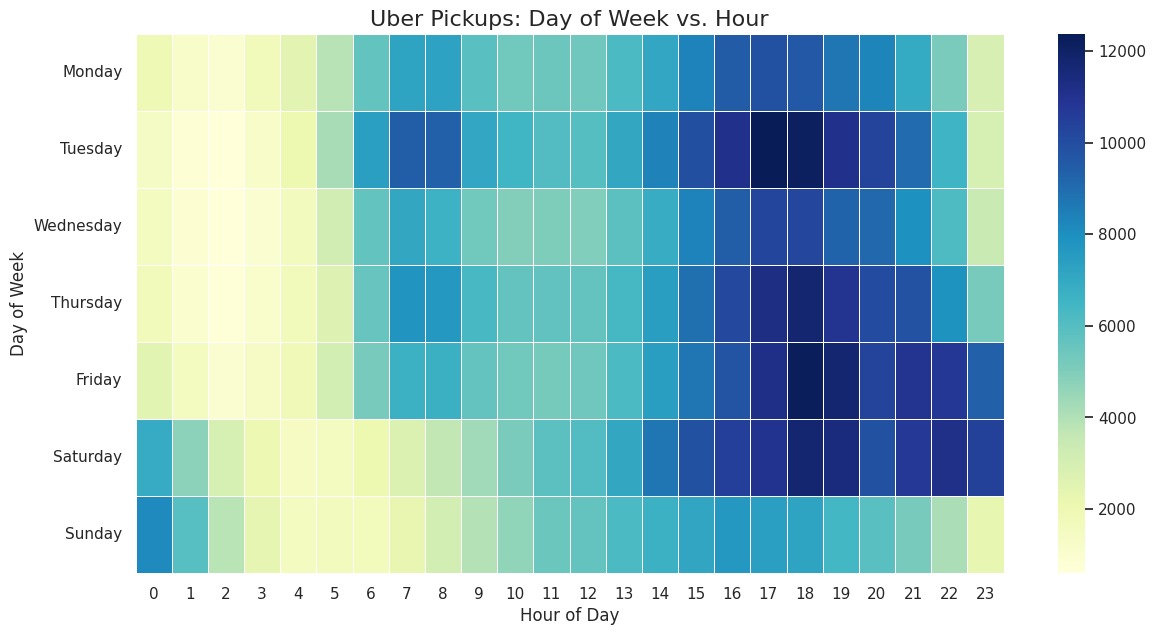

In [3]:
# Group the data to count rides for every combination of Day and Hour
pivot_data = df.groupby(['DayOfWeek', 'Hour']).size().unstack()

# Reorder the days logically (otherwise pandas sorts them alphabetically)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_data = pivot_data.reindex(days_order)

# Render the Heatmap
plt.figure(figsize=(14, 7))
sns.heatmap(pivot_data, cmap='YlGnBu', linewidths=0.5)
plt.title('Uber Pickups: Day of Week vs. Hour', fontsize=16)
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

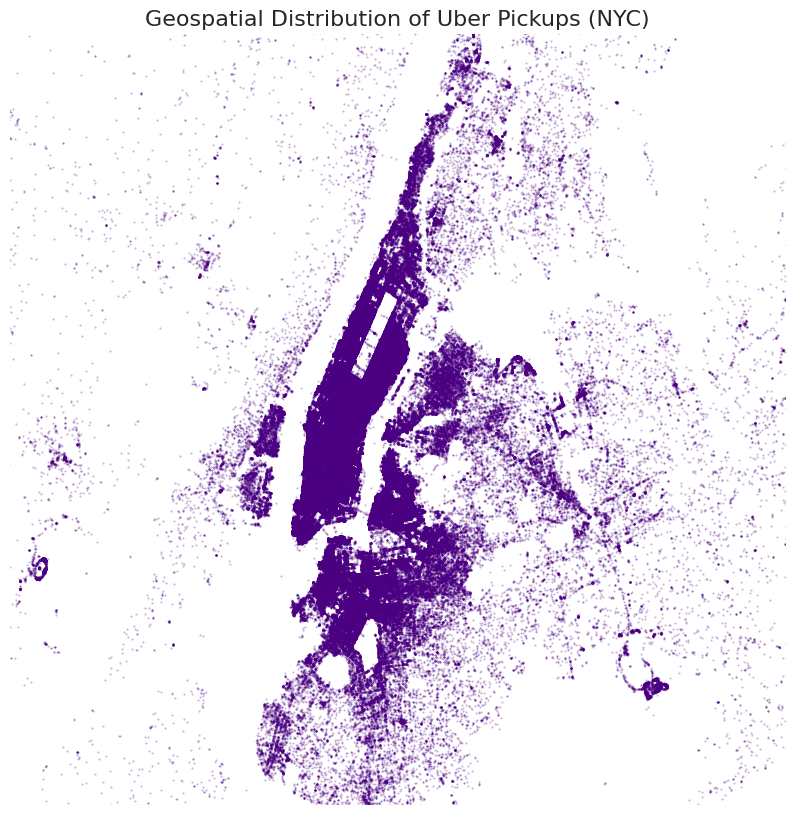

In [4]:
plt.figure(figsize=(10, 10))

# Plot the Longitude (x-axis) and Latitude (y-axis)
# We use a very small marker size (ms=1) and low opacity (alpha=0.3)
# because plotting hundreds of thousands of points will otherwise turn into a solid blob
plt.plot(df['Lon'], df['Lat'], '.', ms=1, alpha=0.3, color='indigo')

# Set the axis limits to roughly focus on the NYC metropolitan area
plt.xlim(-74.2, -73.7)
plt.ylim(40.6, 40.9)

plt.title('Geospatial Distribution of Uber Pickups (NYC)', fontsize=16)
plt.axis('off') # Turn off the grid lines and axes to make it look like a real map
plt.show()

## Resources

### Uber NYC Pickups Analysis

#### Project Overview

This project focuses on performing an exploratory data analysis (EDA) of Uber pickups in New York City during September 2014. The primary goal is to understand the temporal and geographical patterns of Uber rides to identify peak hours, busiest days, and popular pickup locations.

#### Data Source

The dataset used is a subset of Uber trip data for September 2014, obtained from the FiveThirtyEight's Uber TLC FOIL Response dataset. It includes information such as `Date/Time`, `Latitude`, `Longitude`, and `Base`.

#### Key Steps Performed:

*   **Data Loading and Initial Processing**: The dataset was loaded from a CSV file, and the `Date/Time` column was converted to datetime objects for easier manipulation.
*   **Feature Engineering**: New features such as `Hour`, `DayOfWeek`, and `Day` were extracted from the `Date/Time` column to facilitate temporal analysis.
*   **Exploratory Data Analysis and Visualization**: Visualizations were created to explore:
    *   **Hourly Distribution**: The total number of Uber pickups across different hours of the day.
    *   **Day of Week vs. Hour Heatmap**: A heatmap illustrating pickup density across various hours and days of the week, revealing daily and weekly patterns.
    *   **Geospatial Distribution**: A scatter plot of `Longitude` and `Latitude` to visualize the geographic spread of pickups within the NYC metropolitan area.

#### Key Insights:

*   Uber pickups in September 2014 in NYC show distinct daily patterns, with a significant increase in activity during evening hours (around 4 PM to 7 PM).
*   Weekdays generally exhibit higher pickup volumes compared to weekends, with Fridays often being the busiest.
*   The heatmap visualization clearly highlights peak demand times, particularly during weekday evenings and relatively lower activity in the early morning hours and late weekends.
*   The geospatial plot indicates high concentrations of pickups in Manhattan, Brooklyn, and Queens, consistent with major urban activity centers in NYC.